In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [2]:
features_df = pd.read_csv('features_engineered.csv')
print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features\n")

Loaded 72629 games with 96 features



In [3]:
exclude_patterns = [
    'game_id', 'game_date', 'season_id', 'team_id',  # Identifiers
    'home_win',  # Target variable
    # Actual game stats (not predictive)
    'fg_pct_home', 'fg_pct_away',
    'fg3_pct_home', 'fg3_pct_away', 
    'ft_pct_home', 'ft_pct_away',
    'reb_home', 'reb_away', 'reb_diff',
    'oreb_home', 'oreb_away',
    'ast_home', 'ast_away', 'ast_diff',
    'stl_home', 'stl_away',
    'blk_home', 'blk_away',
    'tov_home', 'tov_away', 'tov_diff',
    'plus_minus_home', 'plus_minus_away',
]

predictive_features = [
    col for col in features_df.columns 
    if not any(pattern in col for pattern in exclude_patterns)
]

print(f"Identified {len(predictive_features)} predictive features:")
for feat in sorted(predictive_features):
    print(f"  - {feat}")
print()

Identified 53 predictive features:
  - away_ast_L10
  - away_ast_L20
  - away_ast_L5
  - away_elo_before
  - away_fg3_pct_L10
  - away_fg3_pct_L20
  - away_fg3_pct_L5
  - away_fg_pct_L10
  - away_fg_pct_L20
  - away_fg_pct_L5
  - away_games_played
  - away_reb_L10
  - away_reb_L20
  - away_reb_L5
  - away_rest_days
  - away_tov_L10
  - away_tov_L20
  - away_tov_L5
  - away_win_rate_L10
  - away_win_rate_L20
  - away_win_rate_L5
  - elo_diff
  - fg3_pct_diff_L10
  - fg3_pct_diff_L20
  - fg3_pct_diff_L5
  - fg_pct_diff_L10
  - fg_pct_diff_L20
  - fg_pct_diff_L5
  - h2h_total_games
  - home_ast_L10
  - home_ast_L20
  - home_ast_L5
  - home_elo_before
  - home_fg3_pct_L10
  - home_fg3_pct_L20
  - home_fg3_pct_L5
  - home_fg_pct_L10
  - home_fg_pct_L20
  - home_fg_pct_L5
  - home_games_played
  - home_reb_L10
  - home_reb_L20
  - home_reb_L5
  - home_rest_days
  - home_tov_L10
  - home_tov_L20
  - home_tov_L5
  - rest_advantage
  - season_progress
  - season_year
  - win_rate_diff_L10
  - w

In [4]:
correlations = []

for feature in predictive_features:
    if features_df[feature].isna().sum() / len(features_df) > 0.5:
        continue
    
    valid_data = features_df[[feature, 'home_win']].dropna()
    if len(valid_data) > 100:
        pearson_corr, pearson_p = pearsonr(valid_data[feature], valid_data['home_win'])
        
        correlations.append({
            'feature': feature,
            'correlation': pearson_corr,
            'abs_correlation': abs(pearson_corr),
            'p_value': pearson_p,
            'n_samples': len(valid_data)
        })

corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('abs_correlation', ascending=False)


In [5]:
print(f"TOP FEATURES BY CORRELATION WITH HOME WIN")

top_features = corr_df.head(25)

for idx, row in top_features.iterrows():
    print(f"{row['feature']:40s} | Corr: {row['correlation']:7.4f} | p-value: {row['p_value']:.2e}")

print()

TOP FEATURES BY CORRELATION WITH HOME WIN
win_rate_diff_L20                        | Corr:  0.4045 | p-value: 0.00e+00
win_rate_diff_L10                        | Corr:  0.3469 | p-value: 0.00e+00
elo_diff                                 | Corr:  0.3274 | p-value: 0.00e+00
home_elo_before                          | Corr:  0.2561 | p-value: 0.00e+00
win_rate_diff_L5                         | Corr:  0.2560 | p-value: 0.00e+00
away_win_rate_L20                        | Corr: -0.2318 | p-value: 0.00e+00
away_win_rate_L10                        | Corr: -0.2062 | p-value: 0.00e+00
away_elo_before                          | Corr: -0.1956 | p-value: 0.00e+00
fg_pct_diff_L20                          | Corr:  0.1726 | p-value: 0.00e+00
away_win_rate_L5                         | Corr: -0.1709 | p-value: 0.00e+00
fg_pct_diff_L10                          | Corr:  0.1280 | p-value: 8.86e-209
fg_pct_diff_L5                           | Corr:  0.1264 | p-value: 8.21e-202
away_ast_L5                     

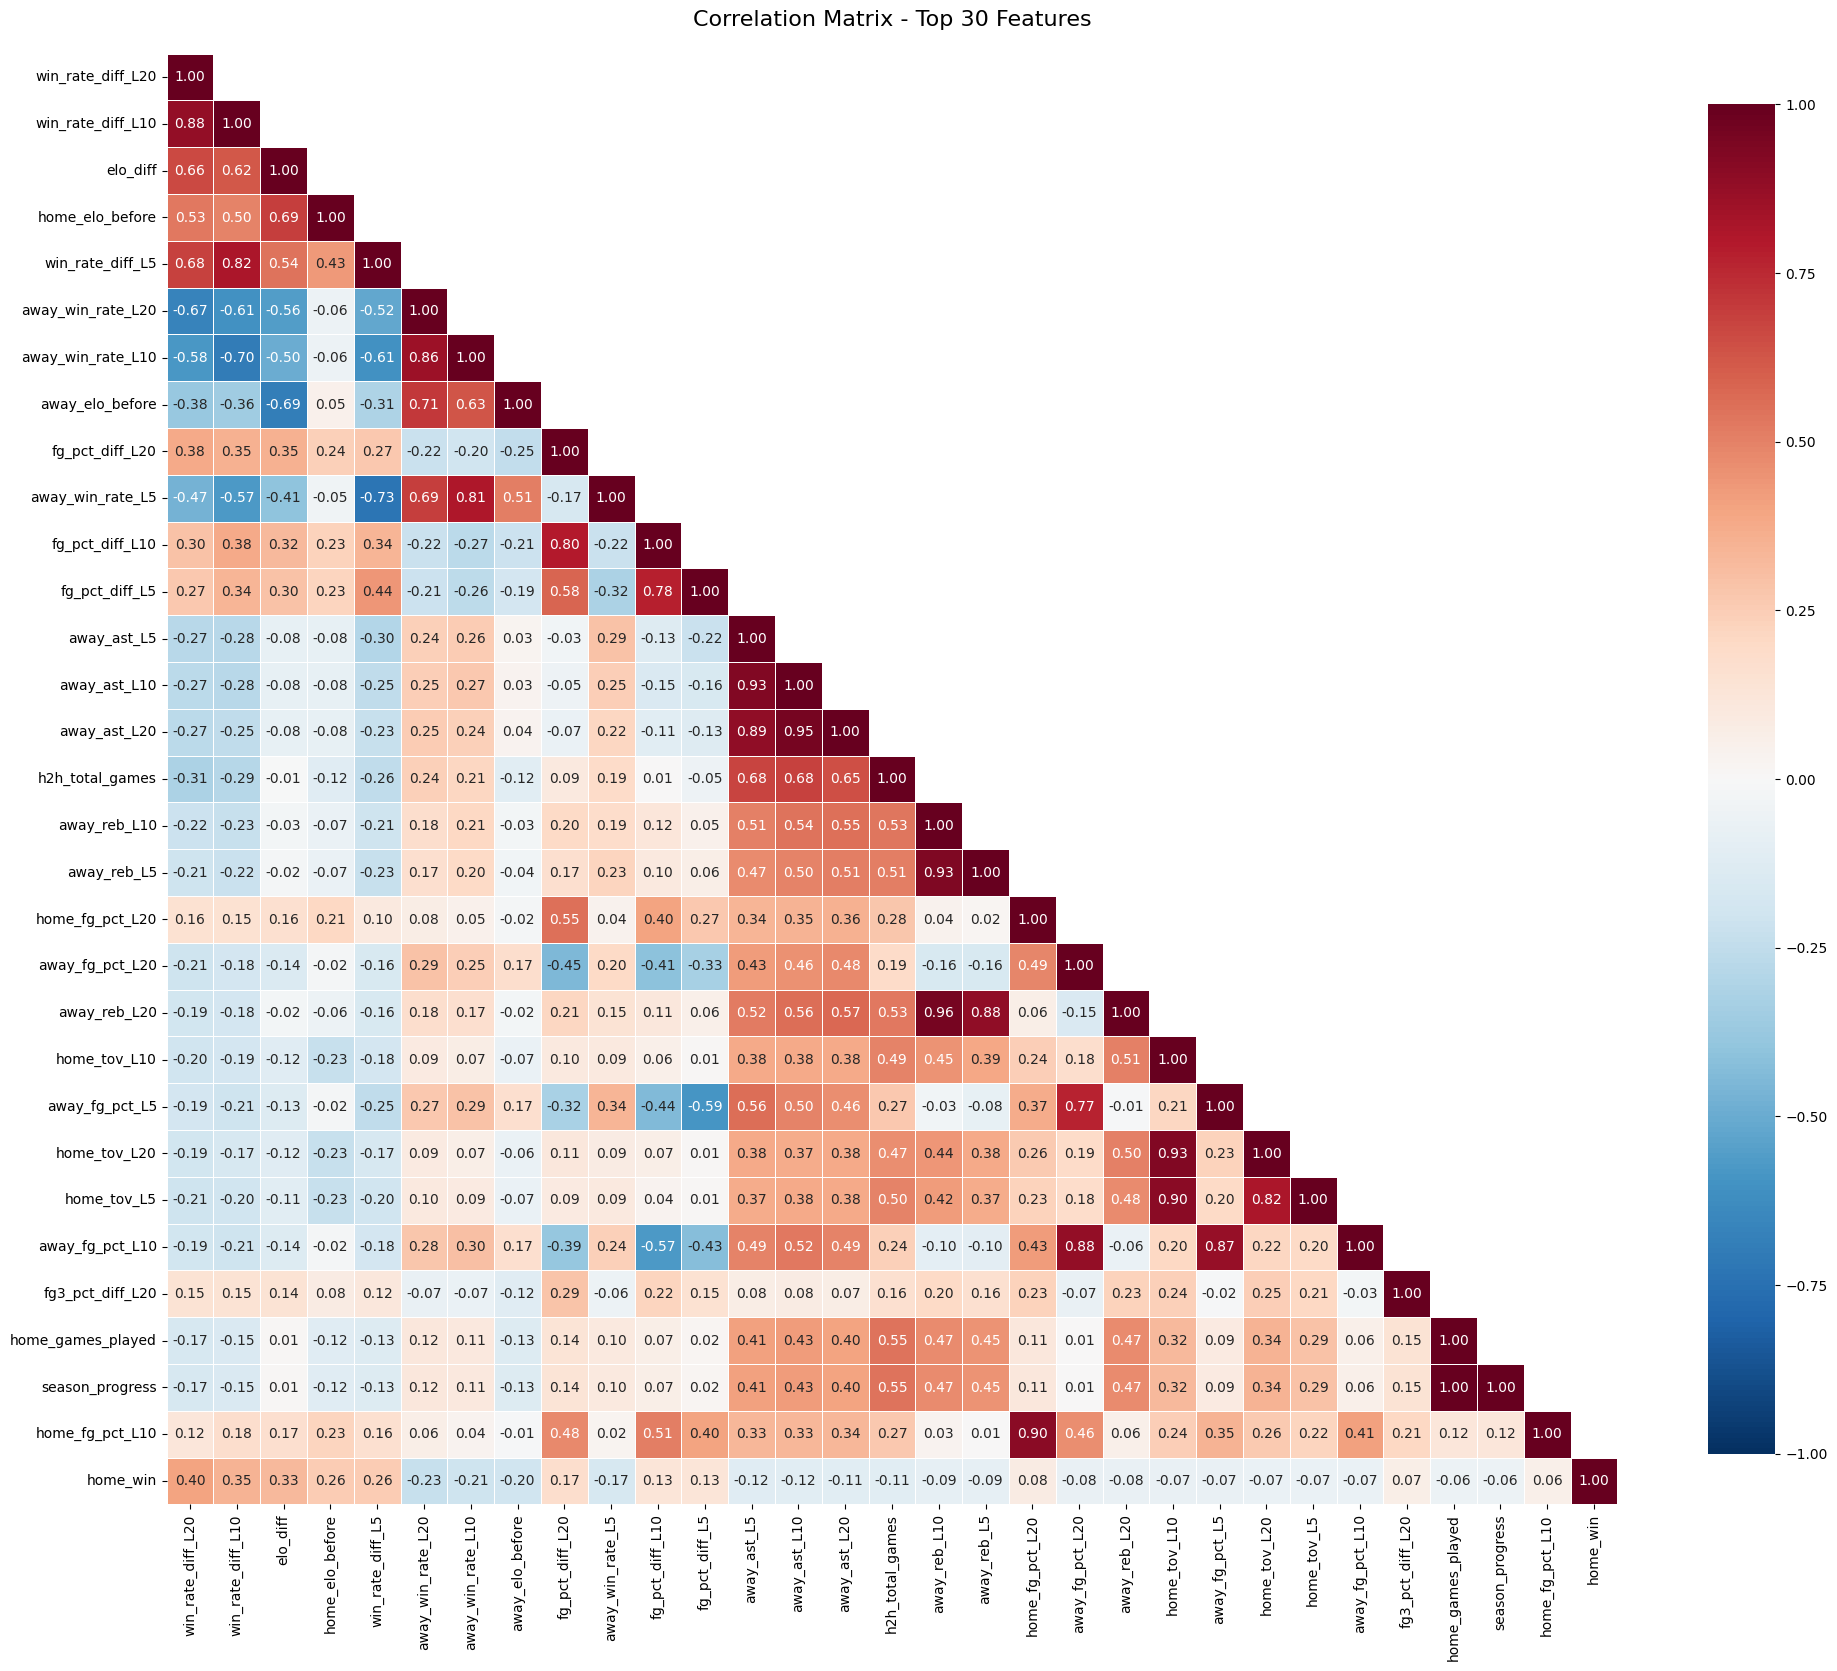

In [6]:
top_features_list = corr_df.head(30)['feature'].tolist()
top_features_list.append('home_win')

corr_matrix = features_df[top_features_list].corr()

plt.figure(figsize=(20, 18))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title(f'Correlation Matrix - Top 30 Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

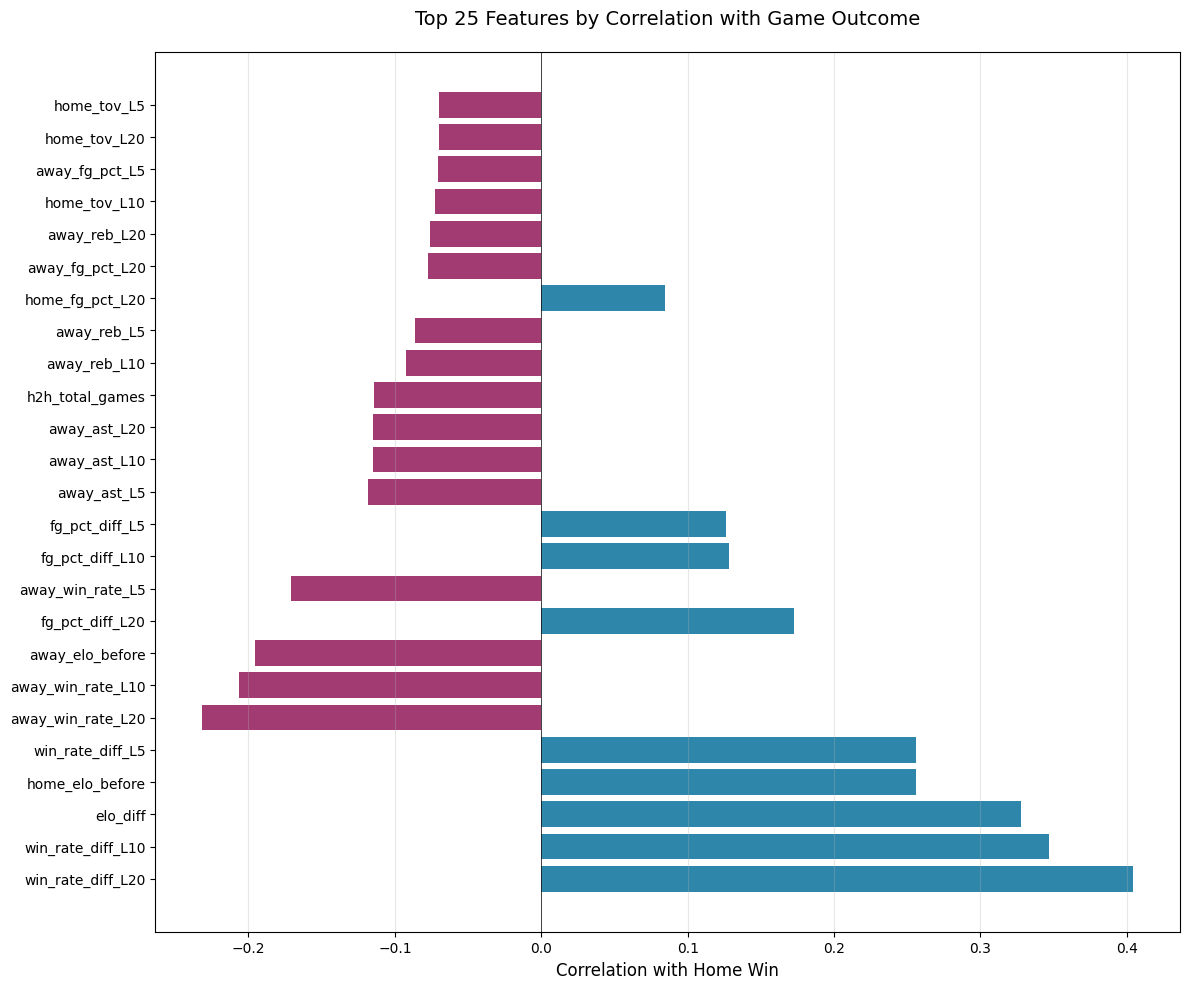

In [7]:
top_features = corr_df.head(25)

plt.figure(figsize=(12, 10))

colors = ['#2E86AB' if x > 0 else '#A23B72' for x in top_features['correlation']]

plt.barh(range(len(top_features)), top_features['correlation'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Correlation with Home Win', fontsize=12)
plt.title(f'Top 25 Features by Correlation with Game Outcome', fontsize=14, pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

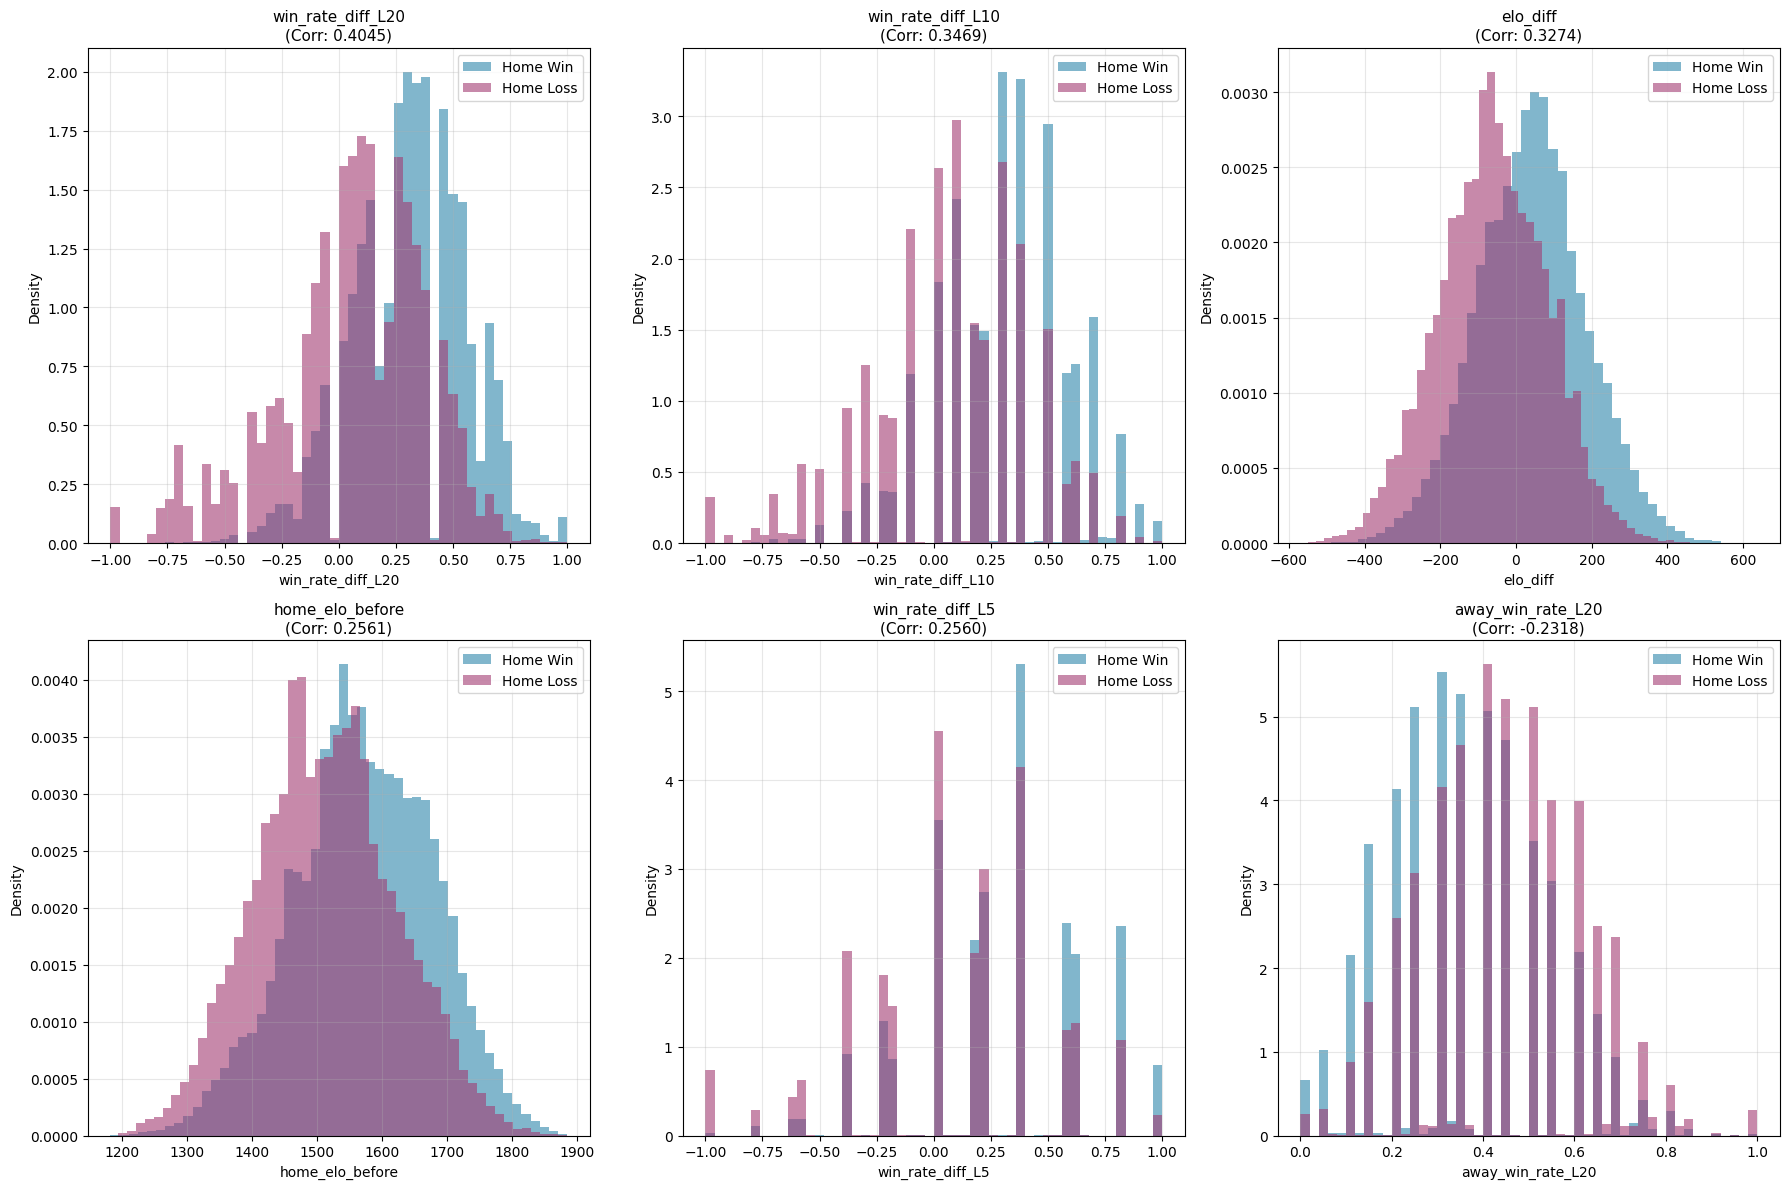

In [8]:
top_features_list = corr_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features_list):
    ax = axes[idx]
    
    # Separate by outcome
    win_data = features_df[features_df['home_win'] == 1][feature].dropna()
    loss_data = features_df[features_df['home_win'] == 0][feature].dropna()
    
    # Plot distributions
    ax.hist(win_data, bins=50, alpha=0.6, label='Home Win', color='#2E86AB', density=True)
    ax.hist(loss_data, bins=50, alpha=0.6, label='Home Loss', color='#A23B72', density=True)
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Add correlation value
    corr_val = corr_df[corr_df['feature'] == feature]['correlation'].values[0]
    ax.set_title(f'{feature}\n(Corr: {corr_val:.4f})', fontsize=11)

plt.tight_layout()
plt.show()

In [9]:

print("TOP 10 FEATURES:")
print("-" * 80)

# Top overall features
top_10 = corr_df.head(10)
for _, row in top_10.iterrows():
    print(f"✓ {row['feature']:40s} | Correlation: {row['correlation']:7.4f}")


TOP 10 FEATURES:
--------------------------------------------------------------------------------
✓ win_rate_diff_L20                        | Correlation:  0.4045
✓ win_rate_diff_L10                        | Correlation:  0.3469
✓ elo_diff                                 | Correlation:  0.3274
✓ home_elo_before                          | Correlation:  0.2561
✓ win_rate_diff_L5                         | Correlation:  0.2560
✓ away_win_rate_L20                        | Correlation: -0.2318
✓ away_win_rate_L10                        | Correlation: -0.2062
✓ away_elo_before                          | Correlation: -0.1956
✓ fg_pct_diff_L20                          | Correlation:  0.1726
✓ away_win_rate_L5                         | Correlation: -0.1709


In [10]:

weak_features = corr_df[corr_df['abs_correlation'] < 0.05]

print(f"{len(weak_features)} FEATURES TO CONSIDER DROPPING (Low Correlation):")
print("-" * 80)
print()

for _, row in weak_features.iterrows():
    print(f"✗ {row['feature']:40s} | Correlation: {row['correlation']:7.4f}")

print()

19 FEATURES TO CONSIDER DROPPING (Low Correlation):
--------------------------------------------------------------------------------

✗ fg3_pct_diff_L5                          | Correlation:  0.0402
✗ home_reb_L5                              | Correlation: -0.0345
✗ season_year                              | Correlation: -0.0339
✗ home_fg3_pct_L10                         | Correlation:  0.0334
✗ home_reb_L10                             | Correlation: -0.0303
✗ away_fg3_pct_L5                          | Correlation: -0.0299
✗ away_tov_L5                              | Correlation:  0.0270
✗ away_fg3_pct_L10                         | Correlation: -0.0260
✗ away_fg3_pct_L20                         | Correlation: -0.0203
✗ away_tov_L10                             | Correlation:  0.0194
✗ home_ast_L20                             | Correlation:  0.0165
✗ home_reb_L20                             | Correlation: -0.0154
✗ home_fg3_pct_L5                          | Correlation:  0.0152
✗ away_t